# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [44]:
import sqlite3
import pandas as pd

In [45]:
db = sqlite3.connect(
    r"C:\Users\HP\Downloads\projects\enterprise_database (1).db"
)

In [46]:
df = pd.read_sql_query(
    "SELECT * FROM users LIMIT 5",
    db
)

print(df)

   user_id          name     status           updated_at
0  U-00000  User_U-00000    Pending  2023-01-01 10:00:00
1  U-00000  User_U-00000     Active  2023-01-19 14:00:00
2  U-00000  User_U-00000  Suspended  2023-02-28 09:00:00
3  U-00001  User_U-00001    Pending  2023-01-01 10:00:00
4  U-00001  User_U-00001     Active  2023-01-28 14:00:00


In [47]:
query = """
WITH ranked_users AS (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
SELECT
    user_id,
    name,
    status,
    updated_at
FROM ranked_users
WHERE rn = 1
AND status = 'Active'
"""

df_active_users = pd.read_sql_query(query, db)

print(f"Active users found: {len(df_active_users):,}")

df_active_users.head()

Active users found: 14,183


,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [48]:
import sqlite3

conn = sqlite3.connect("enterprise_database.db")

cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())

conn.close()

[]


In [49]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("enterprise_database (1).db")

query = """
WITH ranked_users AS (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
SELECT
    user_id,
    name,
    status,
    updated_at
FROM ranked_users
WHERE rn = 1
AND status = 'Active'
"""

df_active_users = pd.read_sql_query(query, conn)

print(f"Active users found: {len(df_active_users):,}")

df_active_users.head()

Active users found: 14,183


,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [50]:
df_logs = pd.read_csv(
    "server_logs (1).txt",
    header=None,
    names=["log"]
)

print(df_logs.head())

                                                 log
0                                     Raw_Server_Log
1  [2023-03-15 00:00:00] INFO: Transaction proces...
2  [2023-09-09 00:00:00] ERROR: Transaction proce...
3  [2023-05-09 00:00:00] INFO: Transaction proces...
4  [2023-10-21 00:00:00] INFO: Transaction proces...


In [51]:
df_logs = pd.read_csv(
    "server_logs (1).txt",
    header=None,
    names=["log"]
)

In [52]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# The log file is actually a well-formed single-column CSV (the log lines are
# quoted, with embedded quotes doubled), so read_csv parses it correctly and
# hands us back clean text lines to run regex over -- no manual line-by-line
# parsing (and no `for` loop) needed.
df_logs = pd.read_csv('server_logs (1).txt')
print(f"Raw logs loaded: {len(df_logs):,}")

# Drop any row where the log line contains "ERROR" (these have no eur_val,
# only a failed_val, and shouldn't be counted as revenue).
df_logs_clean = df_logs[~df_logs['Raw_Server_Log'].str.contains('ERROR', na=False)].copy()
print(f"Rows remaining after dropping ERROR logs: {len(df_logs_clean):,}")

# Vectorized regex extraction with named groups, applied to the whole
# Series at once via .str.extract() -- this is what lets 100k rows run
# in well under a second instead of minutes.
pattern = (
    r'\[(?P<Date>\d{4}-\d{2}-\d{2}).*?'          # log timestamp -> Date
    r'"u":"(?P<User_ID>[^"]+)".*?'                  # "u":"U-xxxxx"
    r'"item_code":"(?P<Product_ID>[^"]+)".*?'       # "item_code":"PRD-xxx"
    r'"eur_val":(?P<Euro_Value>[\d.]+)'             # "eur_val":123.45
)

extracted_data = df_logs_clean['Raw_Server_Log'].str.extract(pattern)
extracted_data['Euro_Value'] = pd.to_numeric(extracted_data['Euro_Value'])
extracted_data['Date'] = pd.to_datetime(extracted_data['Date'])

# Sanity check: make sure every row parsed successfully
print("Rows with any failed extraction:", extracted_data.isna().any(axis=1).sum())

extracted_data.head()

Raw logs loaded: 100,000
Rows remaining after dropping ERROR logs: 94,902
Rows with any failed extraction: 0


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.80
5,2023-05-23,U-13348,PRD-589,4964.77


In [53]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# Load exchange rates
df_rates = pd.read_csv(
    'daily_exchange_rates (1).csv',
    parse_dates=['Date']
)
missing_before = df_rates['EUR_to_USD'].isna().sum()

# Weekend rows have no rate (markets are closed), so forward-fill: Friday's
# rate rolls forward to cover Saturday and Sunday. Data must be sorted by
# Date first (done above) for ffill to roll forward correctly.
df_rates['EUR_to_USD'] = df_rates['EUR_to_USD'].ffill()

print(f"Missing exchange rates before ffill: {missing_before}")
print(f"Missing exchange rates after ffill:  {df_rates['EUR_to_USD'].isna().sum()}")

# Merge cleaned transaction logs with exchange rates on Date (a LEFT join
# keeps every transaction -- with ffill applied, nothing gets dropped for
# missing weekend rates the way an inner join against raw weekend NaNs would).
merged = extracted_data.merge(df_rates, on='Date', how='left')

# Merge with the active-user list from Phase 1 (inner join: only transactions
# from users who are currently Active belong on the CFO dashboard).
df_final = merged.merge(
    df_active_users[['user_id', 'name']],
    left_on='User_ID', right_on='user_id',
    how='inner'
)

# Convert Euro transaction value to USD using the day's exchange rate
df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']

df_final = df_final.drop(columns=['user_id']).rename(columns={'name': 'Customer_Name'})

print(f"Final reconciled transactions: {len(df_final):,}")
df_final.head()

Missing exchange rates before ffill: 104
Missing exchange rates after ffill:  0
Final reconciled transactions: 53,899


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,Customer_Name,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,User_U-19484,4011.220772
1,2023-09-06,U-19484,PRD-412,2984.21,1.188273,User_U-19484,3546.055310
2,2023-12-30,U-19484,PRD-367,3447.70,1.176637,User_U-19484,4056.691198
3,2023-03-13,U-19484,PRD-754,2880.35,1.176902,User_U-19484,3389.889181
4,2023-10-21,U-15882,PRD-284,164.08,1.075350,User_U-15882,176.443420


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

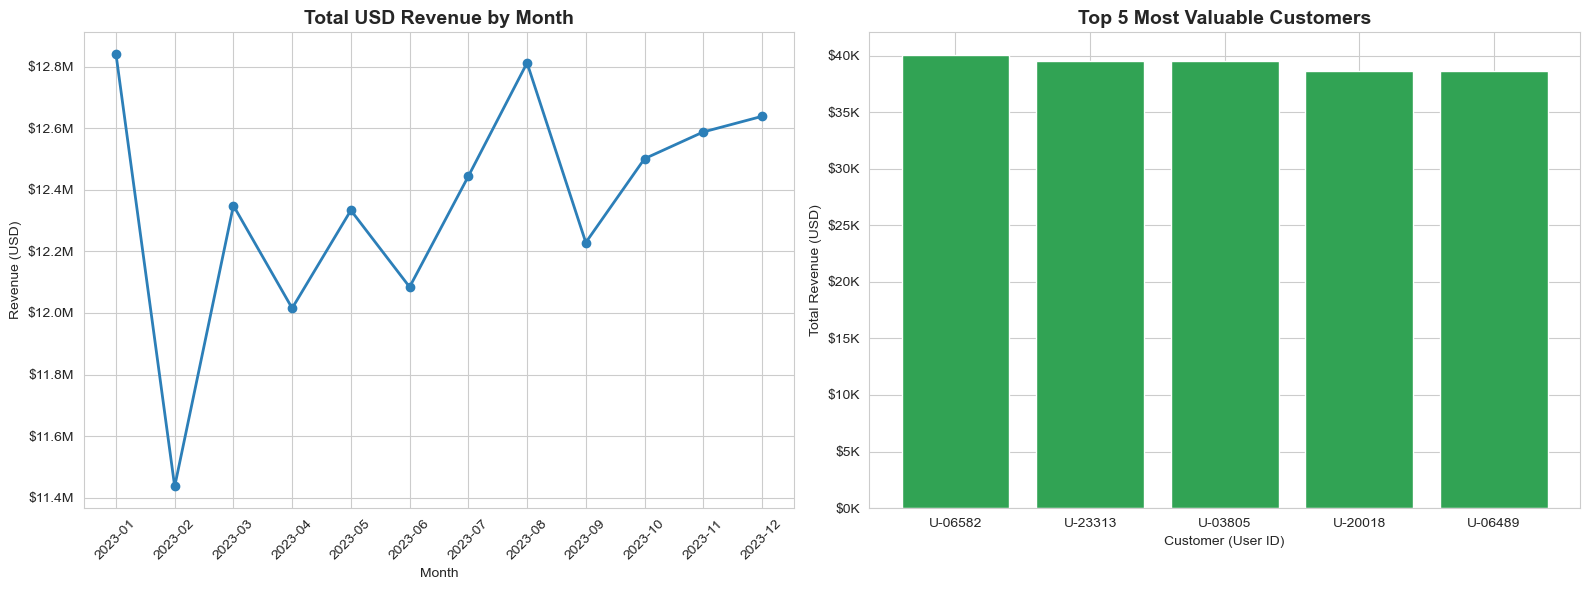


Top 5 Customers:
User_ID Customer_Name  USD_Revenue
U-06582  User_U-06582 40050.988262
U-23313  User_U-23313 39555.806629
U-03805  User_U-03805 39529.945085
U-20018  User_U-20018 38649.965242
U-06489  User_U-06489 38629.142146


In [55]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# --- Aggregation 1: Total USD Revenue by Month ---
df_final['Month'] = df_final['Date'].dt.to_period('M').astype(str)
monthly_revenue = df_final.groupby('Month', as_index=False)['USD_Revenue'].sum()
monthly_revenue = monthly_revenue.sort_values('Month')

# --- Aggregation 2: Top 5 Most Valuable Customers ---
customer_revenue = (
    df_final.groupby(['User_ID', 'Customer_Name'], as_index=False)['USD_Revenue']
    .sum()
    .sort_values('USD_Revenue', ascending=False)
)
top5_customers = customer_revenue.head(5)

# --- Dashboard: two charts side-by-side ---
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Revenue by Month (line chart)
axes[0].plot(monthly_revenue['Month'], monthly_revenue['USD_Revenue'],
             marker='o', color='#2c7fb8', linewidth=2)
axes[0].set_title('Total USD Revenue by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Chart 2: Top 5 Customers (bar chart)
axes[1].bar(top5_customers['User_ID'], top5_customers['USD_Revenue'], color='#31a354')
axes[1].set_title('Top 5 Most Valuable Customers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer (User ID)')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('cfo_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Customers:")
print(top5_customers.to_string(index=False))